# Pulser Validation

Since the dac_capture block has been vetted with the dac_player, I'm vetting the pulser here too before moving on to the RFDC.

In [1]:
def print_attrs(obj, all=False):
    print("Attrs:")
    for attr in dir(obj):
        if all or (not attr.startswith("_")):
            print("  " + attr)

def print_dict(dd, indent=0, depth=-1):
    ind = " "*indent
    for key, val in dd.items():
        print("{}{}:".format(ind, key), end="")
        if hasattr(val, "keys"):
            if depth == 0:
                print(" dict len {}".format(len(val)))
            else:
                print()
                print_dict(val, indent+2, depth-1)
        else:
            print(" {}".format(val))

def print_dicts(obj, depth=-1):
    for dd, name in ((obj.ip_dict, "ip_dict"), (obj.mem_dict, "mem_dict"), (obj.hierarchy_dict, "hierarchy_dict")):
        print(name + ":")
        print_dict(dd, indent=2, depth=depth)

In [2]:
import capture_pulser
import importlib
importlib.reload(capture_pulser)

<module 'capture_pulser' from '/home/xilinx/jupyter_notebooks/RFSoC-MTS/capture_pulser/capture_pulser.py'>

In [3]:
ol = capture_pulser.CapturePulserOverlay('capture_pulser.bit')
ol.is_loaded()

True

In [4]:
ol.download()
ol.is_loaded()

In [4]:
pulser = capture_pulser.PulseGen(ol.pulser_axis_0.mmio.base_addr, count_width=32)

In [4]:
ol.trig_cap.on()

In [5]:
ol.trig_cap.off()

In [6]:
ol.dac_enable.on()

In [7]:
ol.dac_enable.off()

In [8]:
# blink test
import time
for n in range(8):
    ol.trig_cap.on()
    ol.dac_enable.on()
    time.sleep(1)
    ol.trig_cap.off()
    ol.dac_enable.off()
    time.sleep(1)

In [9]:
# Verify some structures in pulser
print(pulser._mem)
for regname, mmio in pulser._mem.items():
    print("{}: base_addr = 0x{:x}".format(regname, mmio.base_addr))
    print("Has MEMORY_MAPPED? {}. Has REGISTER_RW? {}.".format(mmio.device.has_capability("MEMORY_MAPPED"), mmio.device.has_capability("REGISTER_RW")))

{'phase_step_l': <pynq.mmio.MMIO object at 0xffff4fba7070>, 'phase_step_h': <pynq.mmio.MMIO object at 0xffff4fba7070>, 'modulo': <pynq.mmio.MMIO object at 0xffff7c349c90>, 'count_max': <pynq.mmio.MMIO object at 0xffff7c348fd0>, 'amplitude': <pynq.mmio.MMIO object at 0xffff60369cf0>, 'sw_trig': <pynq.mmio.MMIO object at 0xffff4fba75b0>, 'enable': <pynq.mmio.MMIO object at 0xffff4fba7610>, 'trig_counts': <pynq.mmio.MMIO object at 0xffff4fba7670>}
phase_step_l: base_addr = 0xa0010000
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
phase_step_h: base_addr = 0xa0010000
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
modulo: base_addr = 0xa0010004
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
count_max: base_addr = 0xa0010008
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
amplitude: base_addr = 0xa001000c
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
sw_trig: base_addr = 0xa0010010
Has MEMORY_MAPPED? True. Has REGISTER_RW? False.
enable: base_addr = 0xa0010014
Has MEMORY_MAPPED? Tr

In [5]:
pulser.enable()
pulser.get_enable()

1

In [5]:
pulser.enable(False)
pulser.get_enable()

0

In [6]:
from pynq import Clocks

print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')
print(f'FCLK1: {Clocks.fclk1_mhz:10.3f} MHz')
print(f'FCLK2: {Clocks.fclk2_mhz:10.3f} MHz')
print(f'FCLK3: {Clocks.fclk3_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz
FCLK1:     99.999 MHz
FCLK2:     99.999 MHz
FCLK3:     99.999 MHz


# Square pulse
Define pulse duration and amplitude

In [23]:
STREAM_RATE = 5.0e8 # 8 samples per stream; stream is 500 MHz
stream_clk_per_ns = 1.0e9/STREAM_RATE # 2ns stream clock period (resolution of pulse counter)
MAX_AMPLITUDE = (1<<14)-1
COUNTER_WIDTH = pulser.count_width
MAX_PULSE_COUNTS = (1 << COUNTER_WIDTH) - 1

pulse_duration_ns = 50 # 1.0e9 # pulse duration
pulse_amplitude = 0.1 # 0-1 inclusive

pulse_amplitude_counts = min(int(pulse_amplitude*(1<<14)), MAX_AMPLITUDE)
# Recall implied 1/2 of counter LSB frequency relative to clock
pulse_count_max = min(int(pulse_duration_ns/(2*stream_clk_per_ns))-1, MAX_PULSE_COUNTS)

# Set values
pulser.set_count_max(pulse_count_max)
pulser.set_amplitude(pulse_amplitude_counts)

# Readback and confirm
pulse_count_max_readback = pulser.get_count_max()
print("Duration counts: Set {}; readback {}. {}".format(pulse_count_max, pulse_count_max_readback, "PASS" if pulse_count_max_readback == pulse_count_max else "FAIL"))
amplitude_readback = pulser.get_amplitude()
print("Amplitude counts: Set {}; readback {}. {}".format(pulse_amplitude_counts, amplitude_readback, "PASS" if amplitude_readback == pulse_amplitude_counts else "FAIL"))

Duration counts: Set 11; readback 11. PASS
Amplitude counts: Set 1638; readback 1638. PASS


In [14]:
# Read back trigger counts
print(pulser.get_trig_counts())

1


In [7]:
import time
def trigger_capture(ol, pulser=None):
    """ Internal loopback of DAC waveform to internal capture mirror"""
    if pulser is not None:
        pulser.enable(False)
    ol.trig_cap.off()
    #ol.trig_cap.on() # triggers ADCs to capture and pulser to begin
    if pulser is not None:
        pulser.enable()
        #pulser.trigger()
    ol.trig_cap.on()
    time.sleep(1.5)
    ol.trig_cap.off()

## Capture DAC Waveform to Internal Memory
The DAC waveform is saved to an internal memory for verification purposes.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

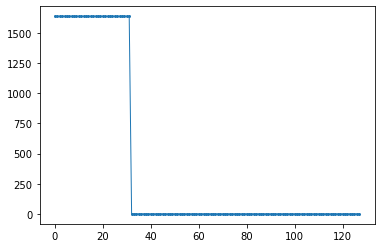

In [24]:
#import time
#time.sleep(2)
#pulser.enable(False)
#pulser.enable()
#ol.trigger_capture()
trigger_capture(ol, pulser)
plt.plot(ol.dac_capture[:128], marker='o', linewidth=1, markersize=2);

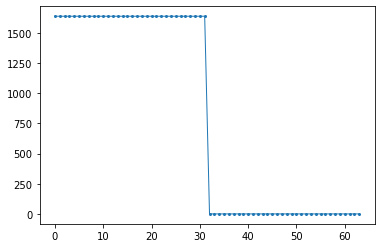

In [25]:
plt.plot(ol.dac_capture[:64], marker='o', linewidth=1, markersize=2);

# Diagnostic tool 0: slow readback

In [21]:
dd = ol.ip_dict["hier_dac_cap/diag_readback_0"]
addr = int(dd["parameters"].get("C_BASEADDR"), 16)
rbk = capture_pulser.DiagReadback(addr) # 0xA0000000

In [22]:
print(rbk.get_trigger_counter())
print(rbk.get_rollover_counter())
print(rbk.get_tvalid_counter())
fdl = rbk.get_first_tdata_list()
#ldl = rbk.get_last_tdata_list()
for data in fdl:
    print("  0x{:08x}".format(data))

7
7
7
  0x06660666
  0x06660666
  0x06660666
  0x06660666
  0x06660666
  0x06660666
  0x06660666
  0x06660666


# Diagnostic tool 1: ILA/DebugBridge

In [9]:
from pynq.lib import DebugBridge
from pynqutils.runtime.repr_dict import ReprDict
base = 0x80000000
high = 0x8000FFFF
dd = {
    "phys_addr": base,
    "addr_range": high-base+1,
    "fullpath": "/debug_bridge_0",
    "parameters": {},
}
bridge = DebugBridge(ReprDict(dd))

In [10]:
bridge.start_xvc_server()

XVC server started
Connection from : ('192.168.2.1', 43012)


In [26]:
if bridge.serverThread is not None:
    bridge.stop_xvc_server()

Client at ('192.168.2.1', 43012) disconnected by stop...
XVC server stopped


In [27]:
if bridge.serverThread is not None:
    print(bridge.serverThread.serverPort)
else:
    print("Server is stopped")

Server is stopped
